In [6]:
import os
import pickle
import dill
import pprint
import itertools
import pathos
import pprint
import functools
from functools import partial
from pathlib import Path
import logging
import json

import pandas as pd
import numpy as np
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression as MI

import json
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')
from src import MMSEMetropolisHastingsEstimator, MAPGradientAscentEstimator, InstantaneousMixtureModel, PosteriorContourLines, ContourLineGraphPlotter, MCMCGraphPlotter, MAPGradientAscentGraphPlotter, ExponentialPrior, LogisticSource, BayesianEstimators, TriangularSource

print(os.cpu_count())

np.random.seed(2000)

8


# 1. NOBS 1k

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 1000
CURTOSE s0: 0.9943018680142313
CURTOSE s1: 1.063862246511789
----------------------------------------------------------------------------------------------------


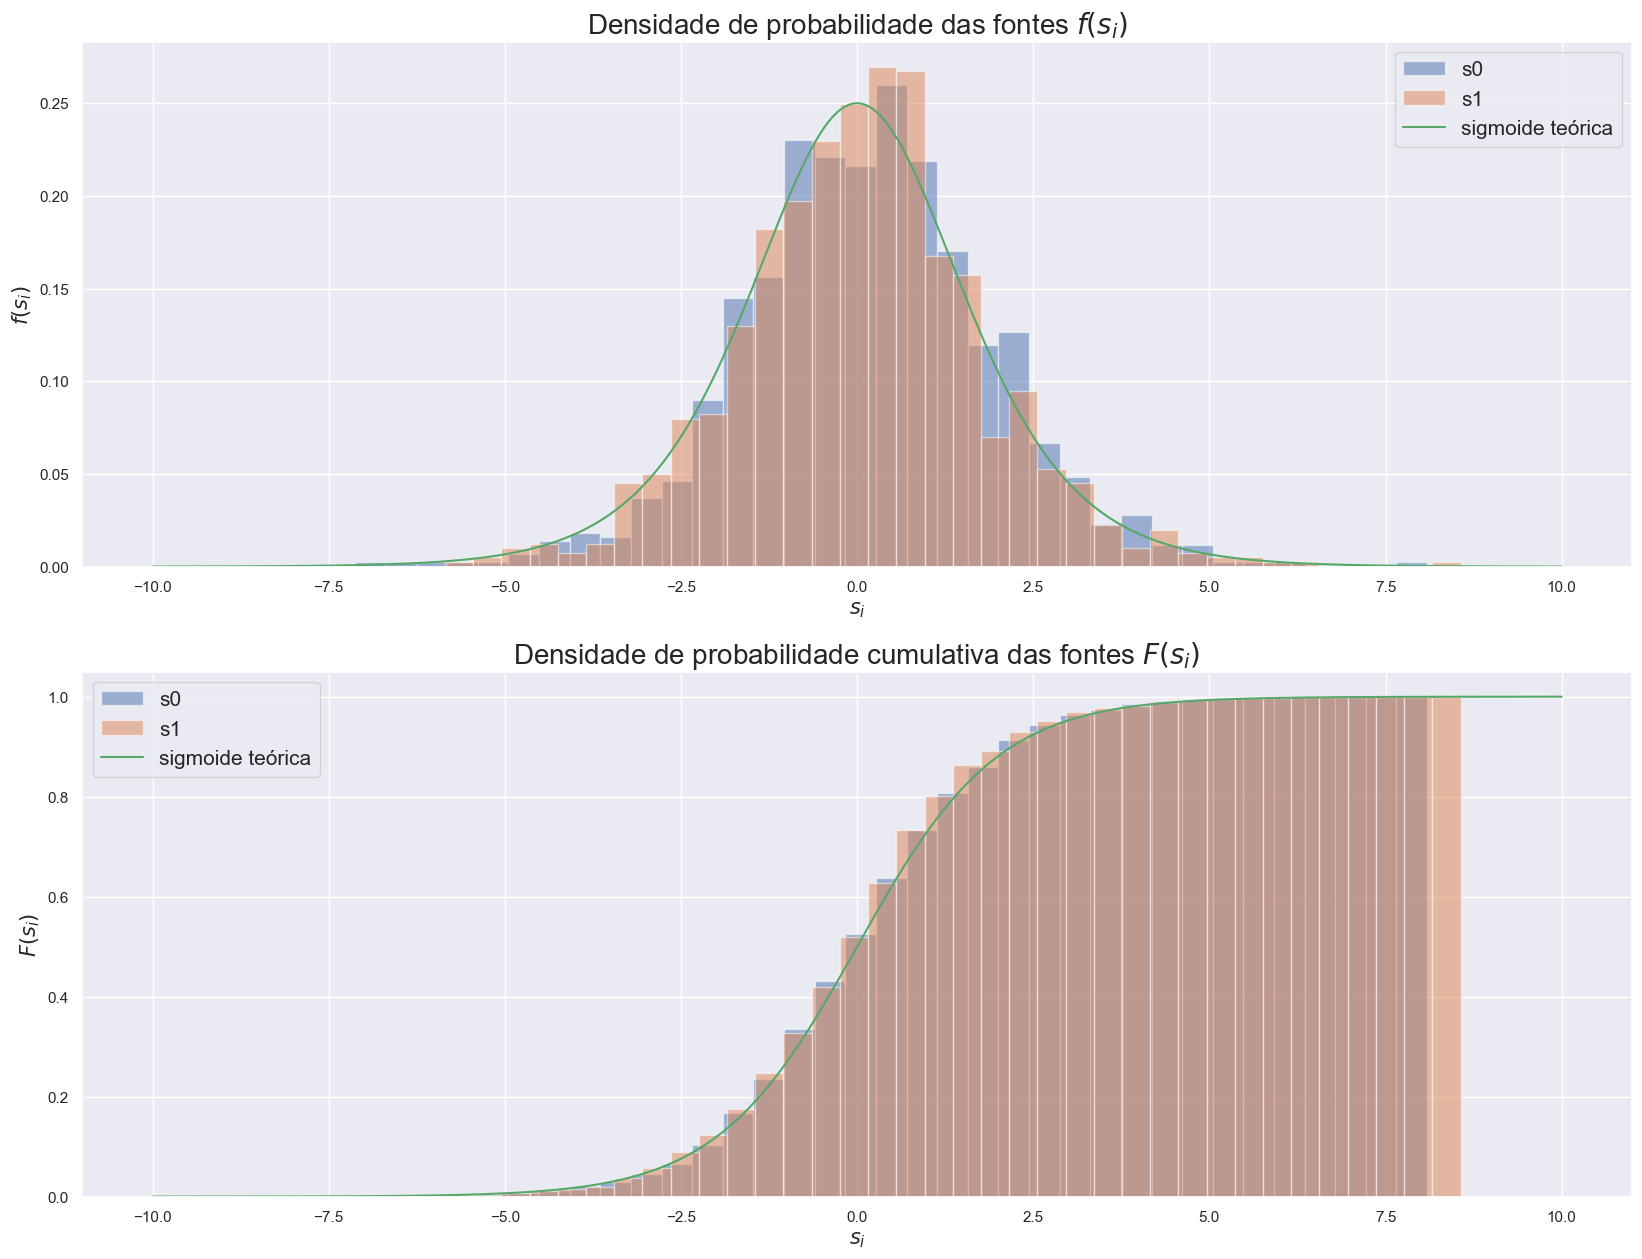

In [7]:
MU=0.0
SIGMA=1.0
NSOURCES=2
NOBS=1000

# Create source model that will be used in experiments
source_model = LogisticSource(
    mu=0,
    sigma=1
)
source_model_pdf = source_model.get()
source_model_pdf_derivative = source_model.get_derivative()
source_model_cumulative = source_model.get_cumulative()

# Initialize source
source = LogisticSource(
    mu=MU,
    sigma=SIGMA
)

# Get source samples
s = source.get_realization(
    nsources=NSOURCES,
    nobs=NOBS
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins='fd',
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins='fd',
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_model_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_model_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

# 2. NOBS 10k

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 10000
CURTOSE s0: 0.906543385749706
CURTOSE s1: 1.2298333261402536
----------------------------------------------------------------------------------------------------


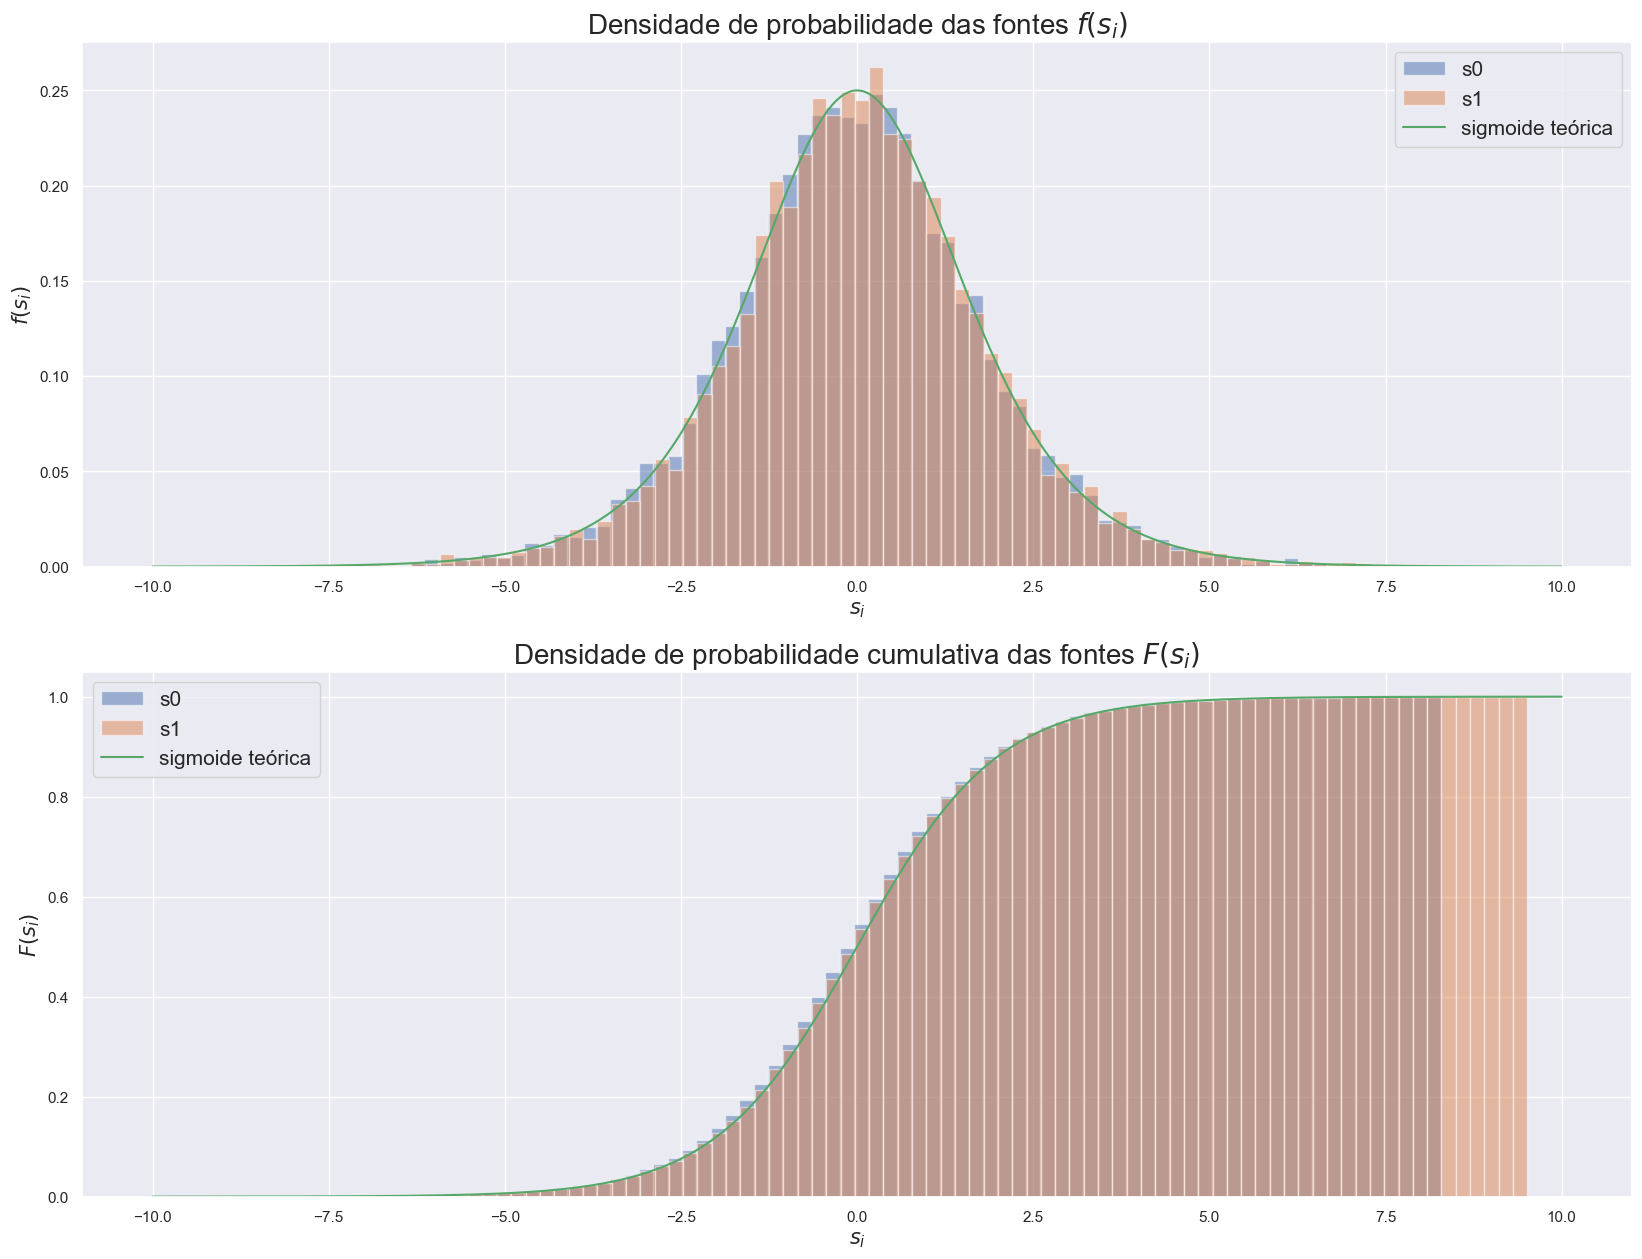

In [9]:
MU=0.0
SIGMA=1.0
NSOURCES=2
NOBS=10000

# Create source model that will be used in experiments
source_model = LogisticSource(
    mu=0,
    sigma=1
)
source_model_pdf = source_model.get()
source_model_pdf_derivative = source_model.get_derivative()
source_model_cumulative = source_model.get_cumulative()

# Initialize source
source = LogisticSource(
    mu=MU,
    sigma=SIGMA
)

# Get source samples
s = source.get_realization(
    nsources=NSOURCES,
    nobs=NOBS
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins='fd',
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins='fd',
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_model_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_model_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

# 3. NOBS 100k

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 100000
CURTOSE s0: 1.2383657773633079
CURTOSE s1: 1.1733438641887082
----------------------------------------------------------------------------------------------------


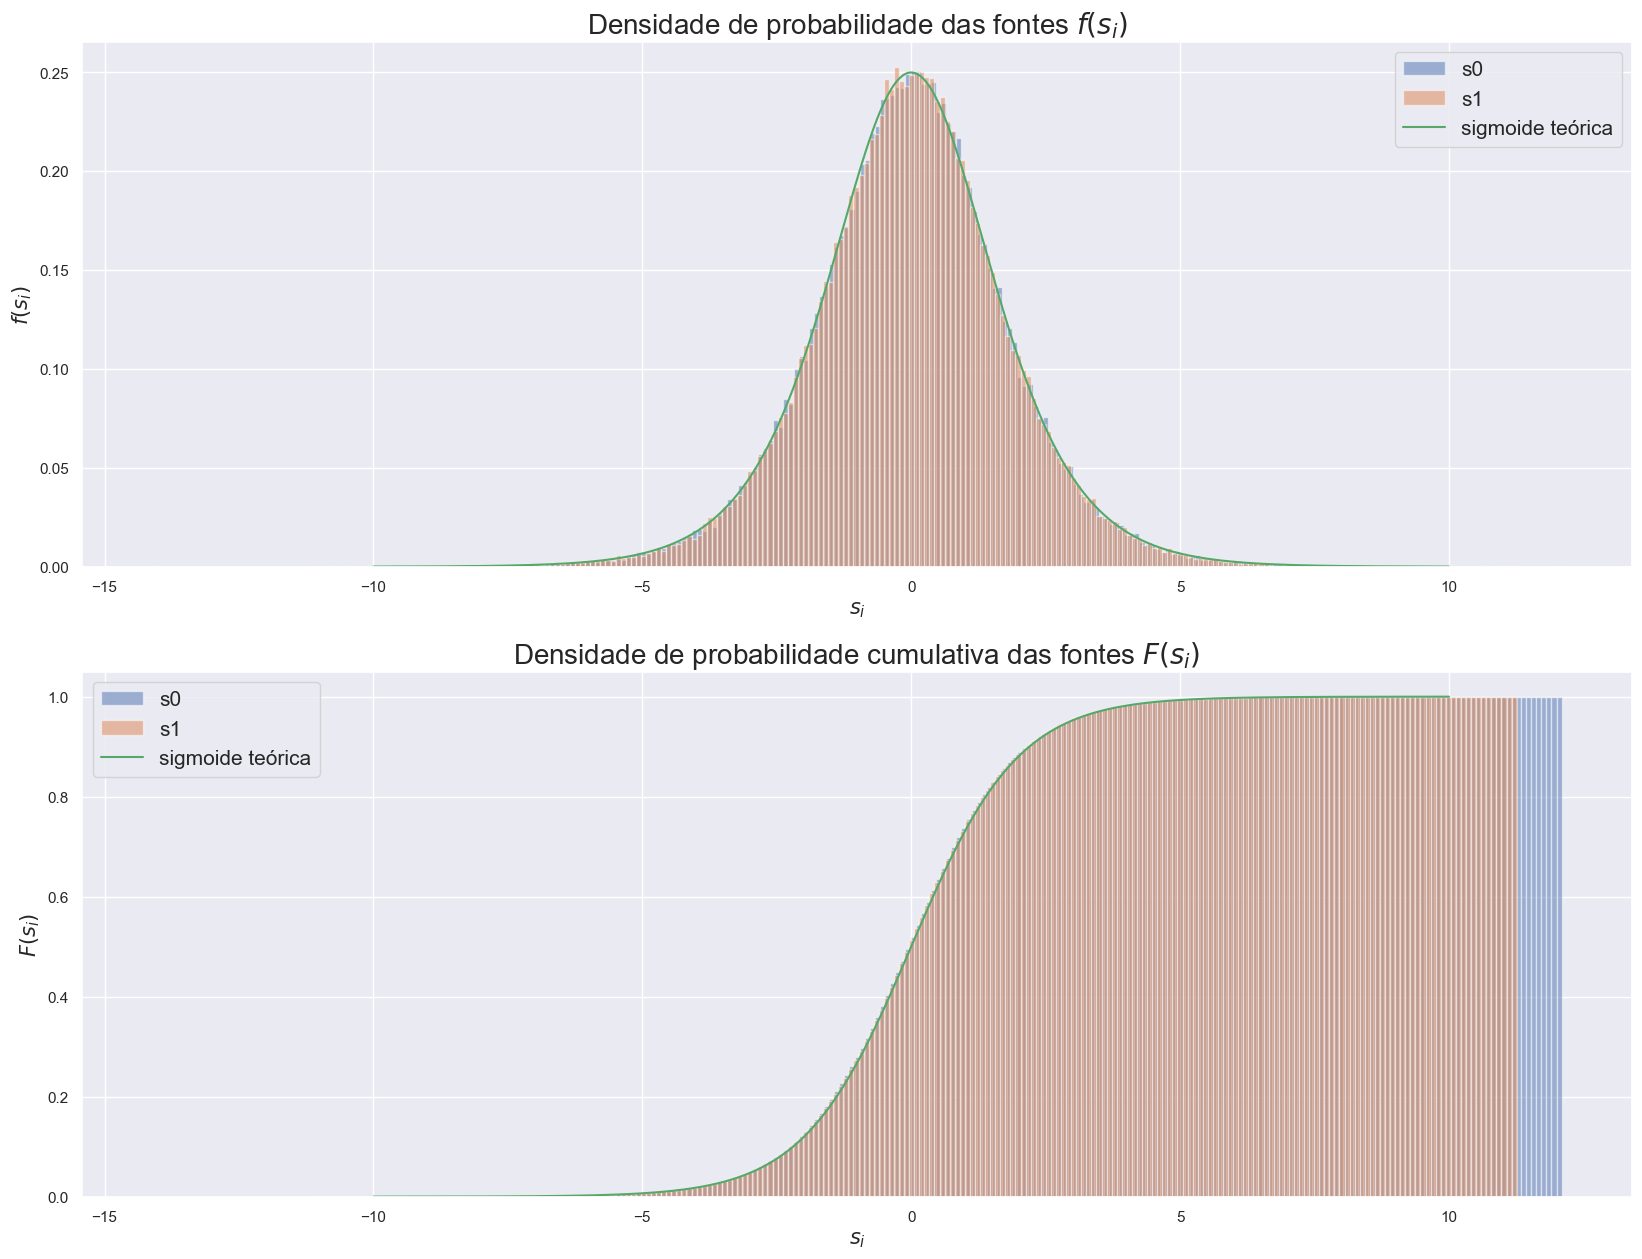

In [10]:
MU=0.0
SIGMA=1.0
NSOURCES=2
NOBS=100000

# Create source model that will be used in experiments
source_model = LogisticSource(
    mu=0,
    sigma=1
)
source_model_pdf = source_model.get()
source_model_pdf_derivative = source_model.get_derivative()
source_model_cumulative = source_model.get_cumulative()

# Initialize source
source = LogisticSource(
    mu=MU,
    sigma=SIGMA
)

# Get source samples
s = source.get_realization(
    nsources=NSOURCES,
    nobs=NOBS
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins='fd',
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins='fd',
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_model_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_model_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)

# 4. NOBS 1M

----------------------------------------------------------------------------------------------------
NÚMERO DE FONTES: 2
TAMANHO DOS SINAIS DAS FONTES: 1000000
CURTOSE s0: 1.2059950060273241
CURTOSE s1: 1.2300854458302188
----------------------------------------------------------------------------------------------------


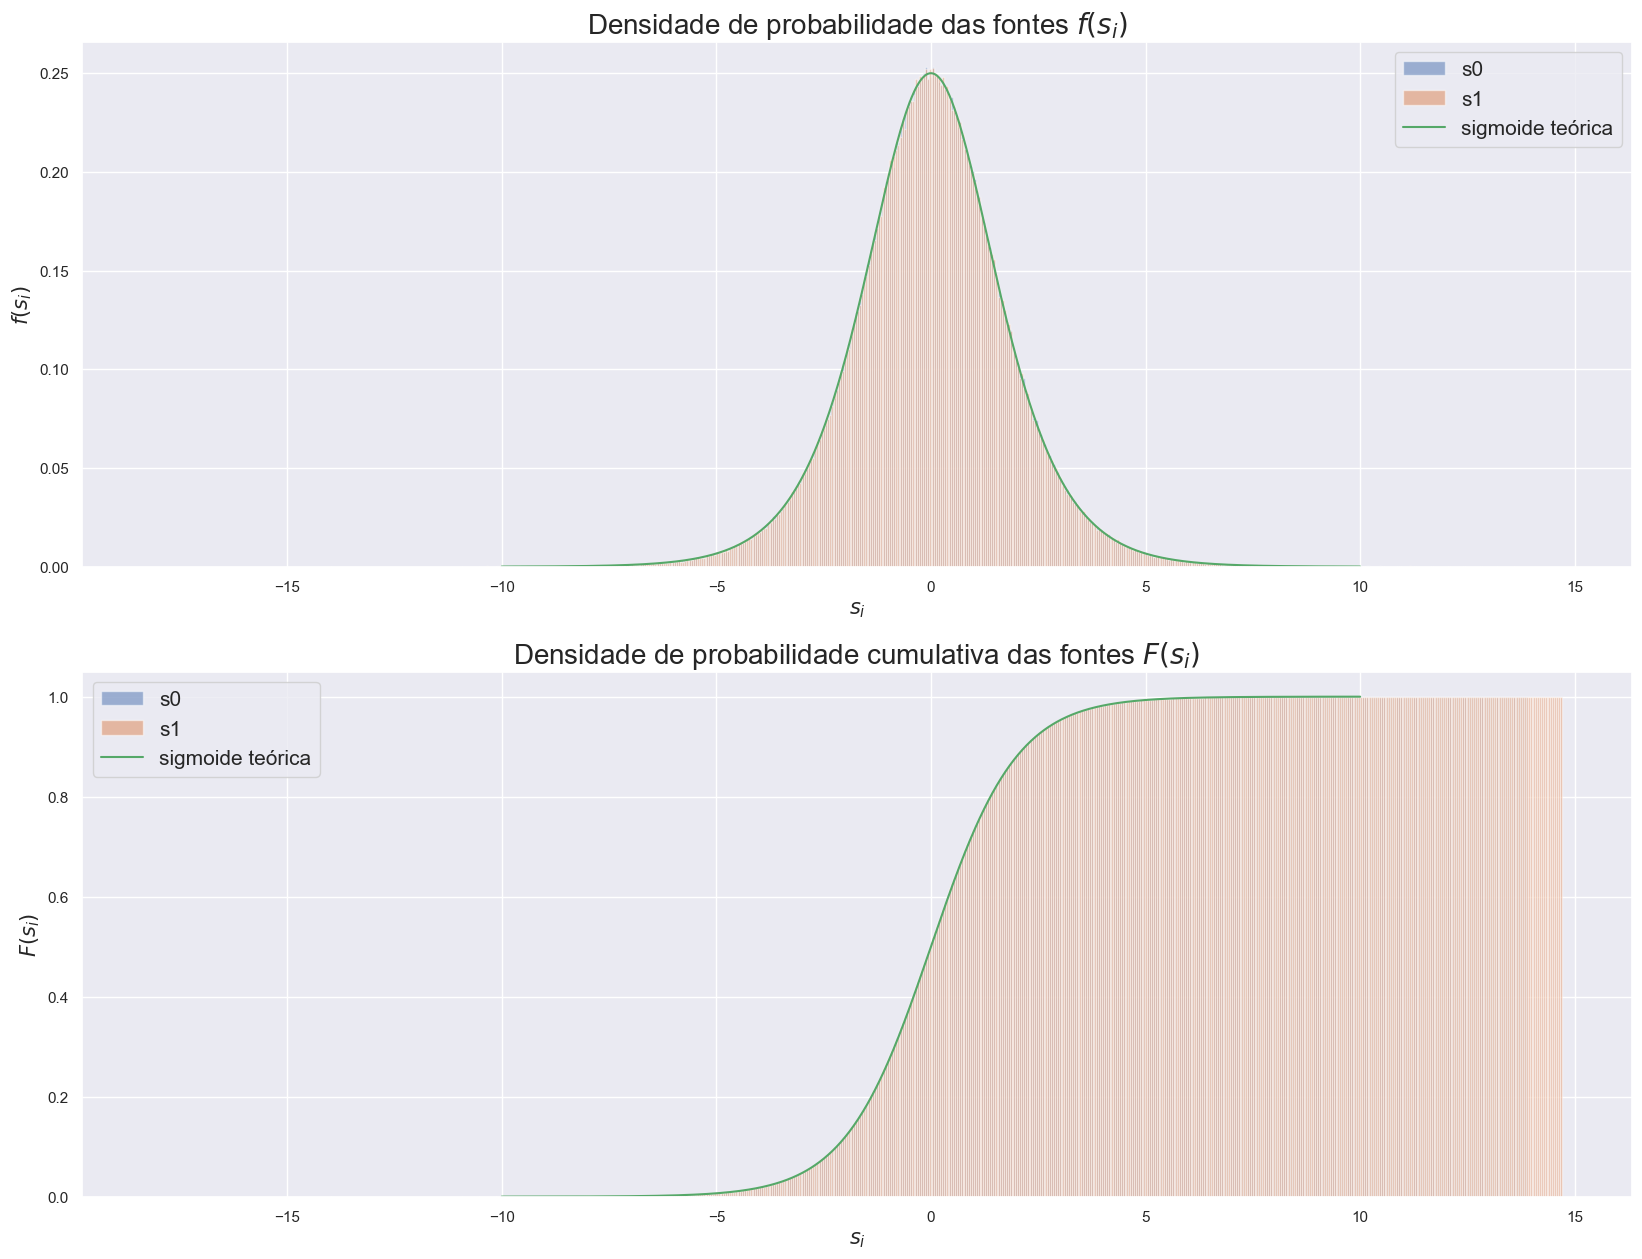

In [11]:
MU=0.0
SIGMA=1.0
NSOURCES=2
NOBS=1000000

# Create source model that will be used in experiments
source_model = LogisticSource(
    mu=0,
    sigma=1
)
source_model_pdf = source_model.get()
source_model_pdf_derivative = source_model.get_derivative()
source_model_cumulative = source_model.get_cumulative()

# Initialize source
source = LogisticSource(
    mu=MU,
    sigma=SIGMA
)

# Get source samples
s = source.get_realization(
    nsources=NSOURCES,
    nobs=NOBS
)

print('-'*100)
print('NÚMERO DE FONTES: {}'.format(NSOURCES))
print('TAMANHO DOS SINAIS DAS FONTES: {}'.format(NOBS))
for i in range(s.shape[0]):
    print(
        'CURTOSE s{}: {}'.format(
            i,
            st.kurtosis(a=s[i,:])
        )
    )
    
print('-'*100)

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)


for i in range(1, NSOURCES+1):
    ax1.hist(
        x=s[i-1,:],
        bins='fd',
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    ax2.hist(
        x=s[i-1,:],
        bins='fd',
        cumulative=True,
        density=True,
        label='s{}'.format(i-1),
        alpha=0.5
    )
    
ax1.plot(
    np.linspace(-10,10,1000),
    [source_model_pdf(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)


ax2.plot(
    np.linspace(-10,10,1000),
    [source_model_cumulative(x) for x in np.linspace(-10,10,1000)],
    label='sigmoide teórica'
)

ax1.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax1.set_ylabel(
    '$f(s_{i})$',
    fontsize=15
)
ax1.set_title(
    'Densidade de probabilidade das fontes $f(s_{i})$',
    fontsize=20
)

ax2.set_xlabel(
    '$s_{i}$',
    fontsize=15
)
ax2.set_ylabel(
    '$F(s_{i})$',
    fontsize=15
)
ax2.set_title(
    'Densidade de probabilidade cumulativa das fontes $F(s_{i})$',
    fontsize=20
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)